# STA272 Lab #4

## Purpose of Lab

Welcome to your fourth weekly tutorial lab!

You are encouraged to refer to lecture content and liberally use course resources.

## Logistics

Due date: The homework is due **11:59pm on Thursday, January 29, 2026.**

You will submit your homework on [MarkUs](https://markus.teach.cs.toronto.edu/markus/).

1. Download this file (`STA272_lab4_student.ipynb`) from JupyterHub. (See [our JupyterHub Guide](../guides/jupyterhub_guide.ipynb) for detailed instructions.)
2. Submit this file to MarkUs under the hw3 assignment. (See [our MarkUs Guide](../guides/markus_guide.ipynb) for detailed instructions.)In this lab, we will practice building and evaluating a logistic regression model using the movie dataset.

## Logistic Regression for Classification

**Research Question:** Can we predict whether a movie will be highly rated based on its characteristics?

We will define a movie as "highly rated" if its `vote_average` is 7.0 or higher on TMDB's 10-point scale.

**Learning Objectives:**
- Create a binary outcome variable for classification
- Explore and transform predictors (log transformation)
- Fit and interpret a logistic regression model
- Calculate and interpret odds ratios
- Evaluate classification models using confusion matrix, accuracy, precision, recall, and F1
- Understand ROC curves and AUC

## Task 1: Load and Explore the Data

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

pd.set_option("display.float_format", "{:.2f}".format)

# Load the data
movies = pd.read_csv("../Lectures/movies.csv")
print(f"Dataset shape: {movies.shape}")
movies.head()

Dataset shape: (5000, 17)


,movie_id,title,revenue,popularity,budget,release_date,runtime,genres,vote_average,production_companies,production_countries,actors,crews,actor_avg_pop,crew_avg_pop,cast_count,crew_count
0,19995,Avatar,2923706026,54.76,237000000,2009-12-16,162,"Action,Adventure,Fantasy,Science Fiction",7.60,"Dune Entertainment,Lightstorm Entertainment,20...","US,GB","Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...","John Refoua(0.2), Stephen E. Rivkin(0.2), Terr...",5.92,1.08,67,991
1,299534,Avengers: Endgame,2799439100,17.86,356000000,2019-04-24,181,"Adventure,Science Fiction,Action",8.24,Marvel Studios,US,"Robert Downey Jr.(8.7), Chris Evans(7.2), Mark...","Paul Schneider(0.3), Louis D'Esposito(1.2), Ca...",8.80,0.46,107,608
2,76600,Avatar: The Way of Water,2353096253,61.95,350000000,2022-12-14,192,"Action,Adventure,Science Fiction",7.60,"20th Century Studios,Lightstorm Entertainment,...",US,"Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...","James Cameron(4.1), James Cameron(4.1), James ...",6.40,2.53,57,205
3,597,Titanic,2264162353,27.67,200000000,1997-12-18,194,"Drama,Romance",7.90,"Paramount Pictures,20th Century Fox,Lightstorm...",US,"Leonardo DiCaprio(9.4), Kate Winslet(6.5), Bil...","James Cameron(4.1), James Horner(0.7), Russell...",4.99,1.98,116,262
4,980477,Ne Zha 2,2259822417,42.19,80000000,2025-01-29,144,"Animation,Fantasy,Adventure,Action",8.12,"Chengdu Coco Cartoon,Beijing Enlight Pictures,...",CN,"Lu Yanting(1.1), Joseph(0.6), Han Mo(1.0), Che...","Jiao Zi(0.6), Jiao Zi(0.6), Liu Wenzhang(0.3),...",0.78,0.42,24,10


## Task 2: Create the Binary Outcome Variable

We will create a binary variable `is_highly_rated` that equals 1 if `vote_average >= 7.0` and 0 otherwise.

A rating of 7.0 or higher on TMDB typically indicates a movie that audiences consider "good" or better.

In [76]:
# Create binary outcome: 1 if vote_average >= 7.0, 0 otherwise
movies['is_highly_rated'] = (movies['vote_average'] >= 7.0).astype(int)

print("Distribution of outcome:")
print(movies['is_highly_rated'].value_counts())
print(f"\nPercentage of highly rated movies: {movies['is_highly_rated'].mean()*100:.1f}%")

Distribution of outcome:
is_highly_rated
0    3063
1    1937
Name: count, dtype: int64

Percentage of highly rated movies: 38.7%


## Task 3: Create a bar plot 

Show the count of highly rated (1) vs. not highly rated (0) movies.

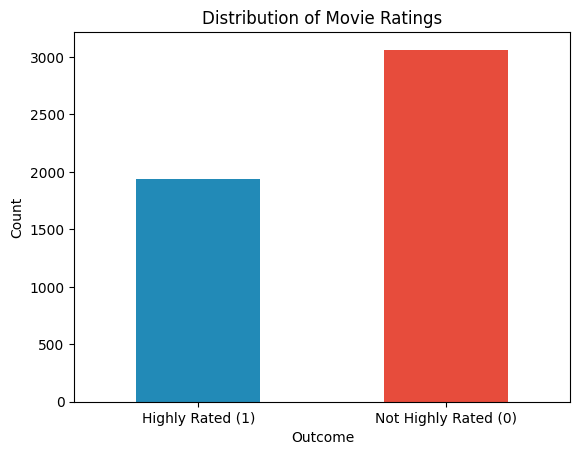

In [77]:
# Bar plot of highly rated vs not
counts = movies['is_highly_rated'].value_counts().reindex([1, 0])

ax = counts.plot(kind='bar', color=["#228ab7", "#e74c3c"])
ax.set_xticklabels(['Highly Rated (1)', 'Not Highly Rated (0)'], rotation=0)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Movie Ratings')
plt.show()

## Exploratory Analysis

Before building our model, let's explore potential predictors. We want to predict whether a movie is highly rated using characteristics like budget, popularity, and runtime.

## Task 4: Distribution of Popularity

Let's first examine the distribution of popularity scores with a histogram.

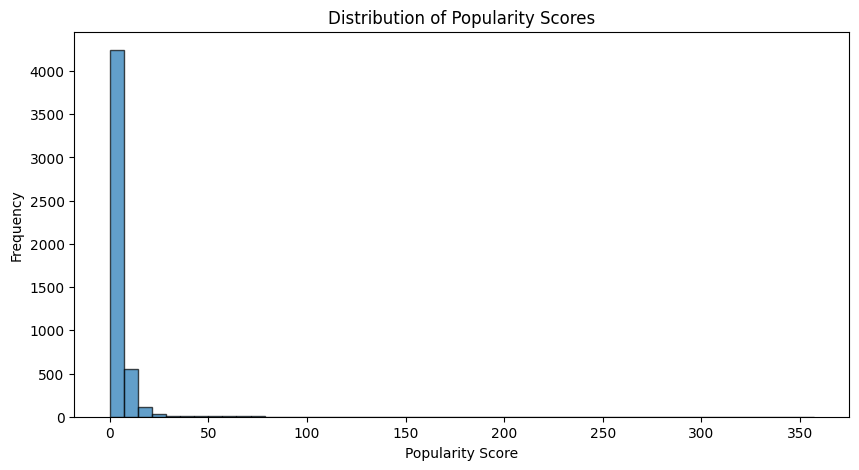

Summary statistics for popularity:
count   5000.00
mean       5.01
std        9.72
min        0.00
25%        1.95
50%        3.42
75%        5.51
max      357.17
Name: popularity, dtype: float64


In [78]:
# Histogram of popularity
plt.figure(figsize=(10, 5))
plt.hist(movies['popularity'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Popularity Scores')
plt.show()

# Summary statistics
print("Summary statistics for popularity:")
print(movies['popularity'].describe())

## Task 5: Log Transform Popularity

The popularity distribution is heavily **right-skewed** - most movies have low popularity scores, but a few have extremely high values. This can cause problems in regression models because:

1. The relationship between popularity and the outcome may not be linear
2. Extreme values can have outsized influence on the model
3. The coefficient is harder to interpret

A **log transformation** can help by:
- Reducing the impact of extreme values
- Making the distribution more symmetric
- Changing interpretation to "percent change" rather than "unit change"

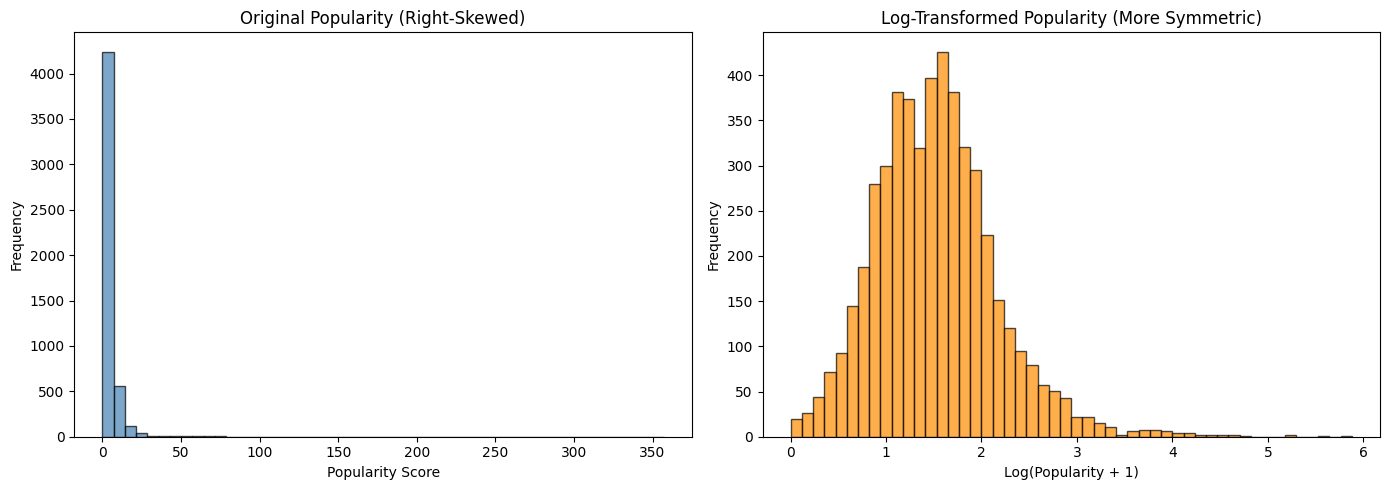

In [79]:
# Create log-transformed popularity
# We add 1 before taking log to handle any zero values: log(x + 1)
movies['log_popularity'] = np.log(movies['popularity'] + 1)

# Compare distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original popularity
axes[0].hist(movies['popularity'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Popularity (Right-Skewed)')

# Log-transformed popularity
axes[1].hist(movies['log_popularity'], bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].set_xlabel('Log(Popularity + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Popularity (More Symmetric)')

plt.tight_layout()
plt.show()

## Task 6: Comparing Log Popularity by Rating Category

Now let's see if there's a difference in log popularity between highly rated and not highly rated movies.

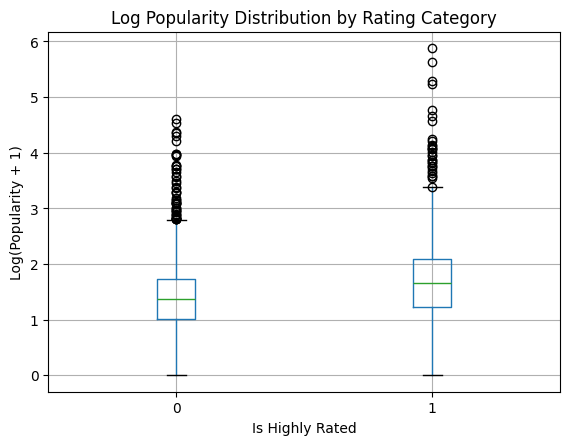

In [80]:
# Boxplot of log_popularity by rating category

movies.boxplot(column='log_popularity', by='is_highly_rated')
plt.xlabel('Is Highly Rated')
plt.ylabel('Log(Popularity + 1)')
plt.title('Log Popularity Distribution by Rating Category')
plt.suptitle('')
plt.show()

**Do you see evidence of a relationship** between log popularity and whether a movie is highly rated? What does this suggest about using popularity as a predictor?

*Your answer here*:

## Task 7: Preparing Logistic Regression Model

Now let's build a multiple logistic regression model to predict whether a movie is highly rated. We'll use:

- Log-transformed popularity
- Budget (in millions)
- Runtime
- Genre indicators (Action, Comedy, Drama, Horror)

In [81]:
# Create budget in millions (handle zeros as missing)
movies_clean = movies[movies['budget'] > 0].copy()
movies_clean['budget_millions'] = movies_clean['budget'] / 1e6

# Create log-transformed popularity for the cleaned data
movies_clean['log_popularity'] = np.log(movies_clean['popularity'] + 1)

# Create genre indicators
genres = ['Action', 'Comedy', 'Drama', 'Horror']
for genre in genres:
    movies_clean[genre.lower()] = movies_clean['genres'].fillna('').str.contains(genre).astype(int)

print(f"Movies with valid budget: {len(movies_clean)}")

Movies with valid budget: 4159


In [82]:
# Define features (using log_popularity instead of raw popularity)
feature_cols = ['budget_millions', 'log_popularity', 'runtime', 'action', 'comedy', 'drama', 'horror']

# Recreate the outcome variable for the cleaned data
movies_clean['is_highly_rated'] = (movies_clean['vote_average'] >= 7.0).astype(int)

X = movies_clean[feature_cols]
y = movies_clean['is_highly_rated']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} movies")
print(f"Test set: {len(X_test)} movies")

Training set: 3327 movies
Test set: 832 movies


## Task 8: Fit the Logistic Regression Model

In [83]:
# Fit multiple logistic regression
X_train_const = sm.add_constant(X_train)
model_multi = sm.Logit(y_train, X_train_const).fit()

# Display coefficients and odds ratios
results = pd.DataFrame({
    'Coefficient': model_multi.params,
    'Odds Ratio': np.exp(model_multi.params),
    'P-value': model_multi.pvalues
})
print(results)

Optimization terminated successfully.
         Current function value: 0.550767
         Iterations 6
                 Coefficient  Odds Ratio  P-value
const                  -3.97        0.02     0.00
budget_millions        -0.01        0.99     0.00
log_popularity          1.39        4.02     0.00
runtime                 0.02        1.02     0.00
action                 -0.77        0.46     0.00
comedy                 -0.51        0.60     0.00
drama                   0.61        1.85     0.00
horror                 -1.23        0.29     0.00


**Which two predictors are most important** for predicting whether a movie is highly rated? 

**Interpret the odds ratio** for `log_popularity`.

*Your answers here:*



## Task 9: Evaluation Metrics

Make predictions on the test set and compute the confusion matrix and classification metrics.

In [84]:
# Make predictions on test set
X_test_const = sm.add_constant(X_test)
y_pred_prob = model_multi.predict(X_test_const)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                    Predicted")
print(f"                    Not HR   HR")
print(f"Actual Not HR       {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"       Highly Rated {cm[1,0]:5d}  {cm[1,1]:5d}")

# Metrics
print(f"\nClassification Metrics for Multiple Model:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

Confusion Matrix:
                    Predicted
                    Not HR   HR
Actual Not HR         434     83
       Highly Rated   149    166

Classification Metrics for Multiple Model:
Accuracy:  0.7212
Precision: 0.6667
Recall:    0.5270
F1 Score:  0.5887


**What does the accuracy** metric of tell us about the model?

*Your answer here:*


## Task 10: ROC Curve and AUC

The **ROC (Receiver Operating Characteristic) curve** shows the trade-off between true positive rate (recall) and false positive rate at different classification thresholds.

The **AUC (Area Under the Curve)** summarizes overall performance:
- AUC = 0.5: No better than random guessing
- AUC = 1.0: Perfect classifier

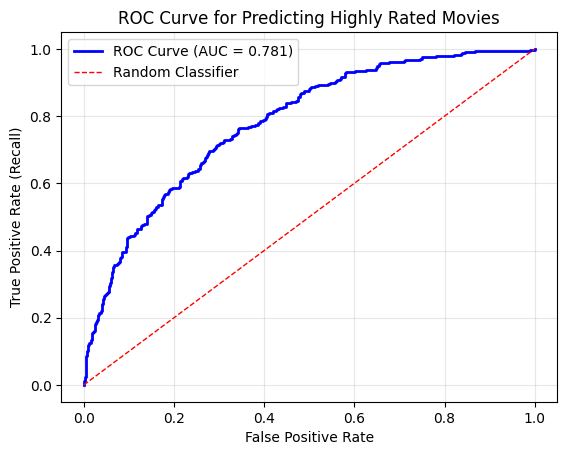

AUC = 0.781


In [85]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

# Plot
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for Predicting Highly Rated Movies')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC = {auc:.3f}")
